In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/interaction_type_bout.csv')
df1['condition'] = 'wiii8'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/interaction_type_bout.csv')
df2['condition'] = 'anosmic'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/interaction_type_bout.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/interaction_type_bout.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/interaction_type_bout.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': '#fc8c59',
    '23129': '#fee2bb',
    '33300': '#fdc38d',
}


In [2]:
df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/distance_travelled.csv')
df1['condition'] = 'wiii8'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/distance_travelled.csv')
df2['condition'] = 'anosmic'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/distance_travelled.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/distance_travelled.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/distance_travelled.csv')
df5['condition'] = '33300'

distance_df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

distance_per_track = distance_df.groupby(['condition', 'file', 'track'], as_index=False)['distance_travelled'].max()

mean_distance_per_file = (
    distance_per_track.groupby(['condition', 'file'], as_index=False)['distance_travelled']
    .mean()
    .rename(columns={'distance_travelled': 'mean_distance_travelled'})
)



      comparison    U        p significance
anosmic vs wiii8  6.0 0.001008           **
   9047 vs wiii8 16.0 0.011330            *
  23129 vs wiii8 26.0 0.075662           ns
  33300 vs wiii8 29.0 0.121225           ns


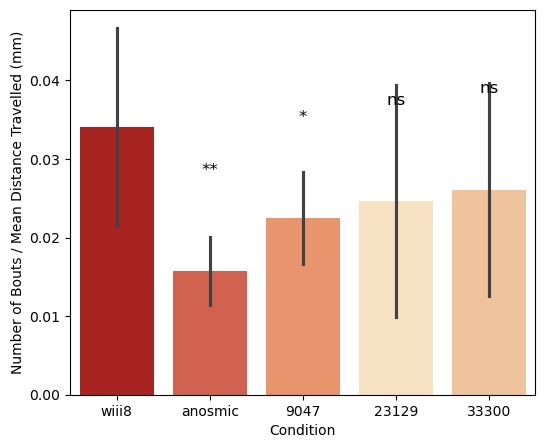

In [3]:
from scipy.stats import mannwhitneyu

bout_counts = (
    df.groupby(['condition', 'file'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)

bout_counts = bout_counts.merge(
    mean_distance_per_file,
    on=['condition', 'file'],
    how='left',
    validate='one_to_one',
)

if bout_counts['mean_distance_travelled'].isna().any():
    missing_files = bout_counts.loc[bout_counts['mean_distance_travelled'].isna(), 'file'].tolist()
    raise ValueError(f'Missing distance data for: {missing_files}')

bout_counts['normalised_n_bouts'] = bout_counts['n_bouts'] / bout_counts['mean_distance_travelled']

control = bout_counts.loc[bout_counts['condition'] == 'wiii8', 'normalised_n_bouts']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = bout_counts.loc[bout_counts['condition'] == condition, 'normalised_n_bouts']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=bout_counts,
    x='condition',
    y='normalised_n_bouts',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

y_offset = bout_counts['normalised_n_bouts'].max() * 0.2
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = bout_counts.loc[bout_counts['condition'] == condition, 'normalised_n_bouts'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Number of Bouts / Mean Distance Travelled (mm)')
plt.xlabel('Condition')
plt.show()

      comparison    U        p significance
anosmic vs wiii8 52.0 0.909722           ns
   9047 vs wiii8 96.0 0.000583          ***
  23129 vs wiii8 41.0 0.520523           ns
  33300 vs wiii8 94.0 0.001008           **


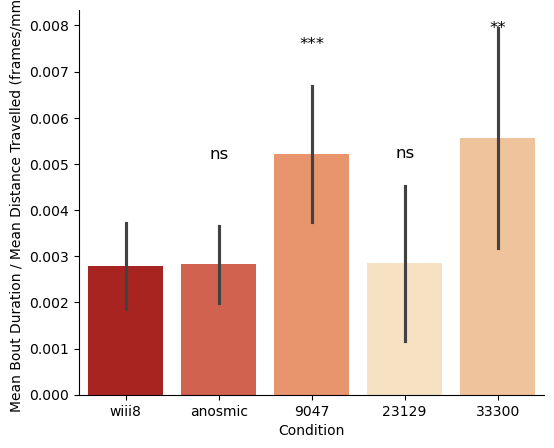

In [4]:
from scipy.stats import mannwhitneyu

duration_per_file = (
    df.groupby(['condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

duration_per_file = duration_per_file.merge(
    mean_distance_per_file,
    on=['condition', 'file'],
    how='left',
    validate='one_to_one',
)

if duration_per_file['mean_distance_travelled'].isna().any():
    missing_files = duration_per_file.loc[duration_per_file['mean_distance_travelled'].isna(), 'file'].tolist()
    raise ValueError(f'Missing distance data for: {missing_files}')

duration_per_file['normalised_mean_bout_duration'] = (
    duration_per_file['mean_bout_duration'] / duration_per_file['mean_distance_travelled']
)

control = duration_per_file.loc[
    duration_per_file['condition'] == 'wiii8',
    'normalised_mean_bout_duration',
]
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = duration_per_file.loc[
        duration_per_file['condition'] == condition,
        'normalised_mean_bout_duration',
    ]
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))


plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=duration_per_file,
    x='condition',
    y='normalised_mean_bout_duration',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

y_offset = duration_per_file['normalised_mean_bout_duration'].max() * 0.2
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = duration_per_file.loc[
        duration_per_file['condition'] == condition,
        'normalised_mean_bout_duration',
    ].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Mean Bout Duration / Mean Distance Travelled (frames/mm)')
plt.xlabel('Condition')
sns.despine()
plt.show()